In [48]:
from networks.cnn_dilated_convolutions import CNNModel
import duckdb
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

con = duckdb.connect('../capillary.db')

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"


df = con.execute(""" 
SELECT id, value,fractions, boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm, label, set, interpretation
                 FROM protein_data
                 WHERE value IS NOT NULL
                 AND observation_nr = 1
                 AND analysis IS NOT NULL
                 AND protein_value IS NOT NULL
""").df()

con.close()

df = df[
    (df['fractions'].apply(len) == 6) &
    (df['boundaries'].apply(len) == 12)
]
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"

from scipy.ndimage import uniform_filter1d

feature_names = [
    "Alb%", "A1%", "A2%", "B%", "Beta2%", "Gamma",
    *[f"Gräns {i}" for i in range(12)],
    "Albumin", "Antitrypsin", "Orosomukoid",
    "Haptoglobin", "CRP", "IgG", "IgA", "IgM"
]

def plot_occlusion(occlusion, raw_curve=None, smooth=False, smooth_size=10):
    """
    Args:
        saliency_curve:   (300,)
        saliency_tabular: (26,)
        raw_curve:        (300,) om du vill plotta råsignalen ovanför, annars None
        smooth:           True om du kör på enskilt sample
        smooth_size:      Smoothing-fönster, ignoreras om smooth=False
    """
    occ = uniform_filter1d(occlusion, size=smooth_size) if smooth else occlusion

    # --- Kurva ---
    if raw_curve is not None:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
        fig.suptitle("Occlusion – kurvsignal", fontsize=14)
        ax1.plot(range(300), raw_curve, color="steelblue", linewidth=1.2)
        ax1.set_ylabel("Signalvärde")
        ax2.plot(range(300), occ, color="tomato", linewidth=1.5)
        ax2.fill_between(range(300), occ, alpha=0.3, color="tomato")
        ax2.set_ylabel("Känslighet")
        ax2.set_xlabel("Mätpunkt")
    else:
        fig, ax2 = plt.subplots(figsize=(12, 3))
        ax2.set_title("Occlusion – kurvsignal")
        ax2.plot(range(300), occ, color="tomato", linewidth=1.5)
        ax2.fill_between(range(300), occ, alpha=0.3, color="tomato")
        ax2.set_ylabel("Känslighet")
        ax2.set_xlabel("Mätpunkt")

    plt.tight_layout()
    plt.show()

def plot_occlusion_tabular(sensitivity):
    feature_names = [
        "Alb%", "A1%", "A2%", "B%", "Beta2%", "Gamma",
        *[f"Gräns {i}" for i in range(12)],
        "Albumin", "Antitrypsin", "Orosomukoid",
        "Haptoglobin", "CRP", "IgG", "IgA", "IgM"
    ]

    colors = ["tomato" if s > 0 else "steelblue" for s in sensitivity]

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(range(26), sensitivity, color=colors)
    ax.set_xticks(range(26))
    ax.set_xticklabels(feature_names, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("Känslighet (sannolikhetsförändring)")
    ax.set_title("Occlusion – tabellfeatures")
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    plt.tight_layout()
    plt.show()


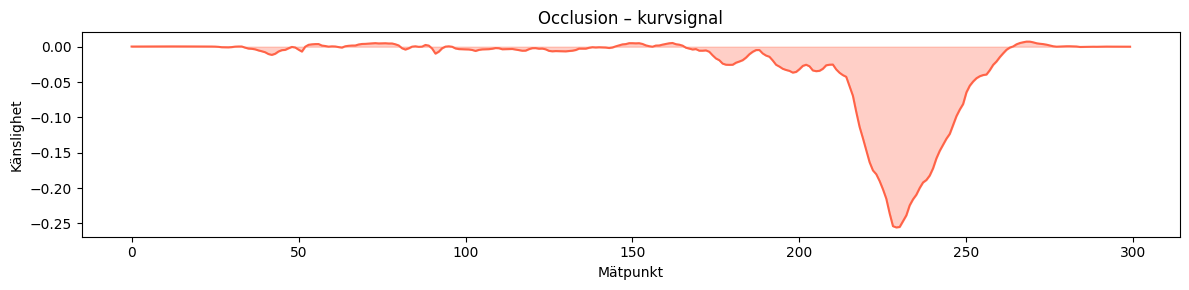

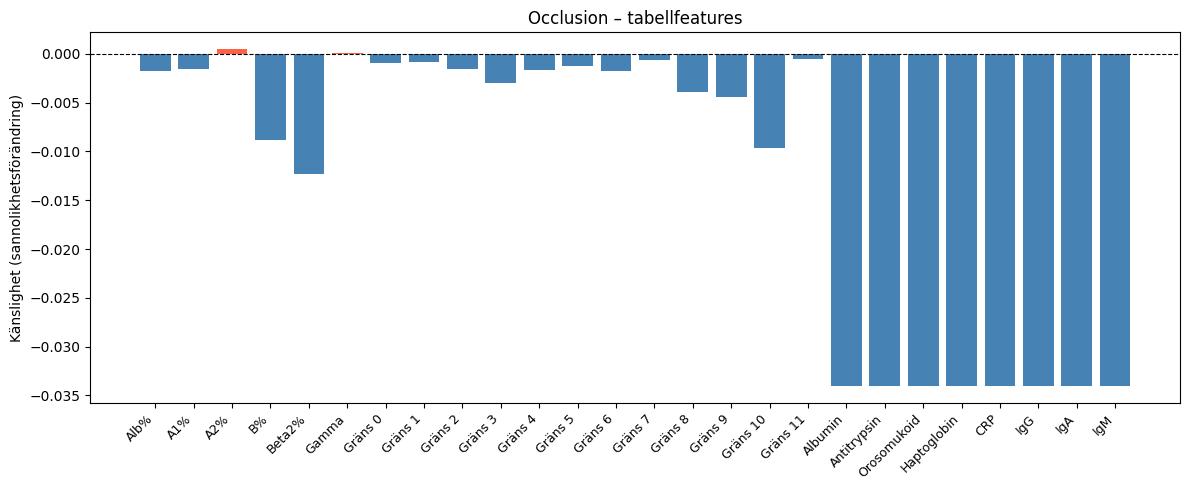

In [49]:
## Kolla hur den hittar M-komponent
model = CNNModel()

averages = torch.tensor(np.stack(df['value'].values).mean(axis=0), dtype=torch.float32).to(device)
alles = model._build_X(df)
tabular = alles[:,300:]
tab_avgs = torch.tensor(np.mean(tabular,axis=0)).to(device)

def occlude(model, x,window_size=5):
    change = np.zeros(300)
    with torch.no_grad():
        baseline = torch.softmax(model(x),dim=1)[:,1].cpu().numpy().mean()
    for i in range(0,300):
        masked_curve = x.clone()
        top_index = min(300,i+window_size)
        masked_curve[:,i:top_index] = averages[i:top_index]
        with torch.no_grad():
            change[i] = torch.softmax(model(masked_curve),dim=1)[:,1].cpu().numpy().mean()

    sensitivity = -(np.ones(300)*baseline - change) 
    return sensitivity

def occlude_tabular(model, x):
    change = np.zeros(26)
    with torch.no_grad():
        baseline = torch.softmax(model(x),dim=1)[:,1].cpu().numpy().mean()
    for i in range(26):
        masked_table = x.clone()
        masked_table[:,300+i] = tab_avgs[i]
        with torch.no_grad():
            change[i] = torch.softmax(model(masked_table),dim=1)[:,1].cpu().numpy().mean()

    sensitivity = -(np.ones(26)*baseline - change) 
    return sensitivity



rows = df[df['label'] == 1].reset_index(drop=True)
X_np = model._build_X(rows)
model = model.model

batch_size = 512
batch_idx = 0
x = torch.tensor(X_np).to(device)
batch = x[batch_idx*batch_size: (batch_idx +1)*batch_size]
model.eval()

sensitivity = occlude(model,batch,40)

plot_occlusion(sensitivity)

sensitivity = occlude_tabular(model,batch)
plot_occlusion_tabular(sensitivity)


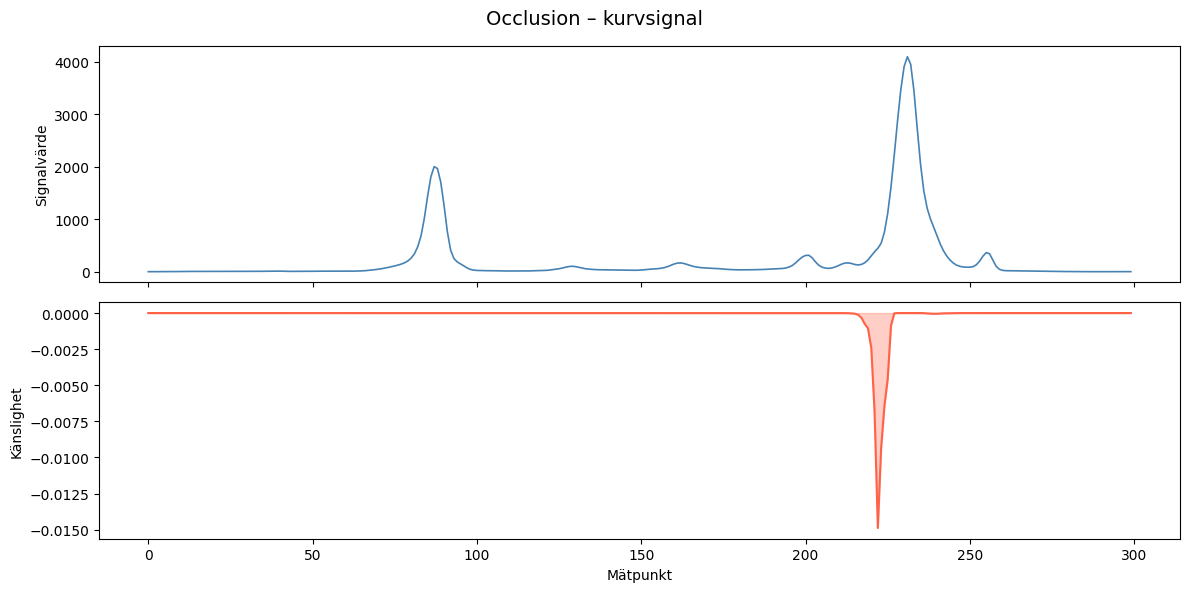

In [47]:
with torch.no_grad():
    probs = torch.softmax(model(x), dim=1)[:, 1].cpu().numpy()

best_idx = np.argmax(probs)  # Mest säkert positiva samplet
x_single = x[best_idx:best_idx+1]
sensitivity = occlude(model, x_single, window_size=50)

plot_occlusion(sensitivity,rows.loc[best_idx,'value'])